# Decision Tree Modelling

Target Class Distribution:
Default_Status
0    0.577452
1    0.422548
Name: proportion, dtype: float64

     MODEL EVALUATION RESULTS
Accuracy:      0.8539
F1 Score:      0.8140
ROC-AUC Score: 0.8455
RMSE:          0.3823
------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       127
           1       0.88      0.76      0.81        92

    accuracy                           0.85       219
   macro avg       0.86      0.84      0.85       219
weighted avg       0.86      0.85      0.85       219



/tmp/ipython-input-3121628687.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='viridis')



Top 10 Features:
 DTI_Ratio             0.570734
Risk_Flag             0.344419
Has_Asset             0.020013
Credit_Score          0.018445
Loan_Term_Months      0.011422
Loan_Amount           0.011381
Annual_Income         0.010914
Age                   0.005402
Occupation_Medical    0.004313
Occupation_Student    0.002325
dtype: float64


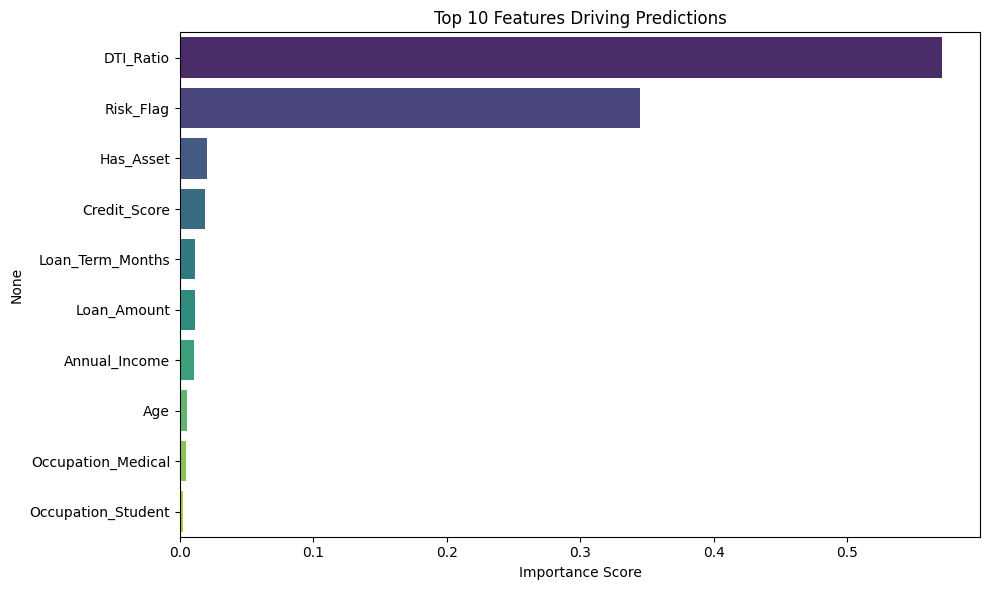

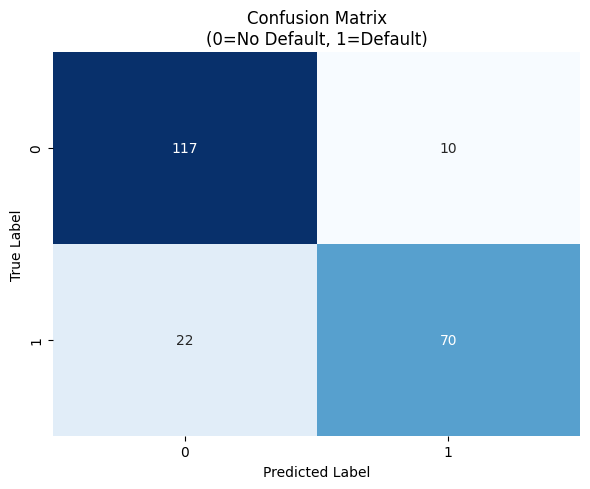

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, roc_curve, classification_report, confusion_matrix

# ==========================================
# 1. Data Loading & Cleaning
# ==========================================
filename = 'synthetic_data_cleaned_feature_engineered.csv'
# Use pipe separator '|' as seen in dataset
df = pd.read_csv(filename, sep='|')

# Fix 'Log_Income;' column (remove trailing semicolon and convert to float)
if 'Log_Income;' in df.columns:
    df.rename(columns={'Log_Income;': 'Log_Income'}, inplace=True)
    df['Log_Income'] = df['Log_Income'].astype(str).str.replace(';', '').astype(float)

# ==========================================
# 2. Feature Engineering & Preprocessing
# ==========================================
# Drop columns that are not useful for the baseline model
# - Customer_ID: Just an identifier
# - Loan_Officer_Note: Unstructured text (needs LLM/NLP processing)
df_model = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# One-Hot Encoding for the categorical 'Occupation' column
df_model = pd.get_dummies(df_model, columns=['Occupation'], drop_first=True)

# Define Features (X) and Target (y)
target_col = 'Default_Status'
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Print class distribution (0 = No Default, 1 = Default)
print("Target Class Distribution:")
print(y.value_counts(normalize=True))

# ==========================================
# 3. Model Training
# ==========================================
# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Decision Tree Classifier
# max_depth=5 prevents overfitting and keeps the tree readable
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# ==========================================
# 4. Prediction & Evaluation
# ==========================================
# Predictions (0 or 1)
y_pred = dt_model.predict(X_test)
# Probabilities (0.0 to 1.0) - needed for ROC-AUC
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*30)
print("     MODEL EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:      {acc:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"ROC-AUC Score: {roc:.4f}")
print(f"RMSE:          {rmse:.4f}")
print("-" * 30)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Top Features (Feature Importance)
feature_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='viridis')
print("\nTop 10 Features:\n", feature_imp)
plt.title('Top 10 Features Driving Predictions')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ==========================================
# 5. Visualizations
# ==========================================

# A. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix\n(0=No Default, 1=Default)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning (GridSearchCV)

In [9]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',  # optimize ROC-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:\n", grid_search.best_params_)

# Best ROC-AUC score from CV
print("Best CV ROC-AUC Score:", grid_search.best_score_)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best Hyperparameters:
 {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV ROC-AUC Score: 0.9212478106751808


In [36]:
# Evaluate Tuned Model

# Get the best estimator
best_dt = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_dt.predict(X_test)
y_pred_proba_tuned = best_dt.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)
roc = roc_auc_score(y_test, y_pred_proba_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("\n" + "="*30)
print(" TUNED MODEL EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:      {acc:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"ROC-AUC Score: {roc:.4f}")
print(f"RMSE:          {rmse:.4f}")
print("-" * 30)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_tuned))


 TUNED MODEL EVALUATION RESULTS
Accuracy:      0.8356
F1 Score:      0.7907
ROC-AUC Score: 0.8675
RMSE:          0.4054
------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.86       127
           1       0.85      0.74      0.79        92

    accuracy                           0.84       219
   macro avg       0.84      0.82      0.83       219
weighted avg       0.84      0.84      0.83       219



# LLM-insights

In [12]:
import google.generativeai as genai

# ==============================
#  CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

In [13]:
# Create a dictionary of model's performance
performance_summary = {
    "Model Type": "Decision Tree Classifier (Baseline)",
    "Accuracy": f"{acc:.4f}",
    "F1-Score": f"{f1:.4f}",
    "ROC-AUC": f"{roc:.4f}",
    "RMSE": f"{rmse:.4f}"
}

In [31]:
import pandas as pd
from sklearn.metrics import classification_report

# ==========================================
#  Dynamic Prompt Generation
# ==========================================

# Extract Top 5 Features automatically
# (Based on the feature_imp series from the previous step)
feature_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features_list = feature_imp.head(5).index.tolist()
top_features_str = ", ".join(top_features_list)

# Calculate Precision and Recall from the classification report
report = classification_report(y_test, y_pred, output_dict=True)
precision = report['1']['precision'] # Precision for the positive class (Default)
recall = report['1']['recall']     # Recall for the positive class (Default)

# Get confusion matrix values
# cm structure: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

# Recreate performance_summary with correct keys and new metrics
performance_summary = {
    "Model Type": "Decision Tree Classifier (Baseline)",
    "Accuracy": acc,  # Using the float value directly
    "F1-Score": f1,    # Using the float value directly
    "ROC-AUC": roc,     # Using the float value directly
    "RMSE": rmse,      # Using the float value directly
    "Precision": precision,
    "Recall": recall
}

# THE PROMPT
prompt = f"""
You are a Lead Data Scientist at a major financial institution.
I have trained a Decision Tree Classifier (max_depth=5) to predict loan defaults.

### 1. Model Context
- Dataset: {X_test.shape[0]} test samples
- Top 5 Features: {top_features_str}

### 2. Performance Summary
- Accuracy: {performance_summary['Accuracy']:.2%}
- ROC-AUC: {performance_summary['ROC-AUC']:.2%}
- Precision: {performance_summary['Precision']:.2%} (Of all predicted defaults, how many were real?)
- Recall: {performance_summary['Recall']:.2%} (Of all real defaults, how many did we catch?)

### 3. Risk Profile (Confusion Matrix)
- Correctly Approved (TN): {tn}
- Correctly Declined (TP): {tp}
- Missed Defaults (FN - Dangerous): {fn} (We approved these bad loans)
- False Alarms (FP - Opportunity Cost): {fp} (We rejected these good customers)

### Request:
Generate a strategic model assessment report covering:
1. Executive Summary: Is this model production-ready?
2. Metric Analysis: Analyze the Precision/Recall trade-off. Is our False Negative count ({fn}) acceptable for a bank?
3. Feature Logic: Do the top features ({top_features_str}) represent logical financial indicators?
4. Tree Structure Advice: Given `max_depth=5`, do these metrics suggest we should prune more (reduce depth) or allow more complexity?
5. Business Impact: Quantify the risk. Are we losing more money on Missed Defaults or lost interest from False Alarms?

Format: Professional Markdown report.
"""


In [32]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)

In [33]:
# ==============================
#  GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
#  OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

## Strategic Model Assessment Report: Loan Default Prediction Model (Decision Tree)

**Date:** October 26, 2023
**To:** Senior Management, Credit Risk Committee
**From:** Lead Data Scientist
**Subject:** Assessment of Decision Tree Classifier for Loan Default Prediction

---

### Introduction

This report provides a strategic assessment of a recently trained Decision Tree Classifier (max_depth=5) designed to predict loan defaults. The model was evaluated on a test set of 219 samples, leveraging key financial indicators. The objective of this assessment is to determine the model's readiness for production, analyze its performance metrics, evaluate the logical soundness of its features, and quantify its potential business impact.

---

### 1. Executive Summary: Is this model production-ready?

**Verdict: Not Production-Ready.**

While the model demonstrates promising overall accuracy (83.56%) and a strong ability to correctly identify non-defaulters (117 TNs), its current performance, pa